In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.svm import SVC
import openpyxl
# Importing all working framworks

In [ ]:
workbook = openpyxl.load_workbook('/content/drive/Shareddrives/Summer_2023_VCell_Ml/Summer 2023  Image analysis/Ua vs Ui Data/Final Data Raw.xlsx')
sheet = workbook.active
# Importing XLSX file

In [ ]:
X_data = []

# Getting all model parameters
for row in sheet.iter_rows(min_row=2, max_row=sheet.max_row, min_col=2, max_col=3):
  X_values = [cell.value for cell in row]
  X_data.append(X_values)

X_data

[[0.025, 0.025],
 [0.025, 0.03],
 [0.025, 0.11],
 [0.025, 0.15],
 [0.025, 0.19],
 [0.025, 0.24],
 [0.03, 0.025],
 [0.03, 0.03],
 [0.03, 0.11],
 [0.03, 0.15],
 [0.03, 0.19],
 [0.03, 0.24],
 [0.04, 0.025],
 [0.04, 0.03],
 [0.04, 0.11],
 [0.04, 0.15],
 [0.04, 0.19],
 [0.04, 0.24],
 [0.045, 0.025],
 [0.045, 0.03],
 [0.045, 0.11],
 [0.045, 0.15],
 [0.045, 0.19],
 [0.045, 0.24],
 [0.049, 0.025],
 [0.049, 0.03],
 [0.049, 0.11],
 [0.049, 0.15],
 [0.049, 0.19],
 [0.049, 0.24]]

In [ ]:
Y_data = []

# Getting all features
for row in sheet.iter_rows(min_row=2, max_row=sheet.max_row, min_col=4, max_col=9):
  Y_values = [cell.value for cell in row]
  Y_data.append(Y_values)

Y_data

[[52,
  0.0965999999999999,
  0.0018576923076923,
  0.000504345026073861,
  0.988896153846153,
  0.0362711156619278],
 [84,
  0.154,
  0.00183333333333333,
  0.00113434828502802,
  0.973658333333333,
  0.0766029018602604],
 [81,
  0.5408,
  0.00667654320987654,
  0.00648851352805004,
  0.719858024691358,
  0.293242839519452],
 [26,
  0.6575,
  0.0252884615384615,
  0.0219814314457081,
  0.463915384615384,
  0.381900945365425],
 [8,
  0.588399999999999,
  0.0735499999999999,
  0.0864652965067488,
  0.334525,
  0.420797804028253],
 [4, 0.0688, 0.0172, 0.00156044865343272, 0.365325, 0.0259131602665518],
 [44,
  0.0601,
  0.00136590909090909,
  0.000231539493801991,
  0.984922727272727,
  0.038964948488915],
 [56,
  0.0888,
  0.00158571428571428,
  0.000465766868197174,
  0.970326785714285,
  0.0532180437011983],
 [100, 0.5162, 0.005162, 0.00554905000878528, 0.803273, 0.25388886342453],
 [76,
  0.5912,
  0.00777894736842105,
  0.00891384664720352,
  0.680661842105263,
  0.294560913621357],

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


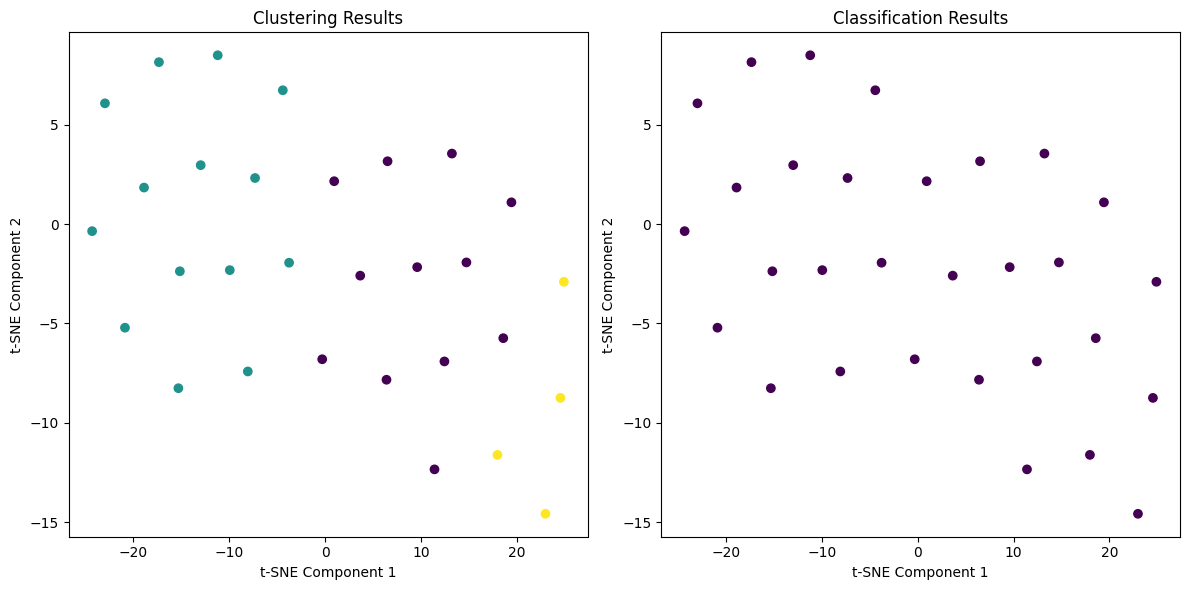

In [ ]:
# Load your dataset
X = np.array(X_data)
Y = np.array(Y_data)

# Clustering example (K-means)
kmeans = KMeans(n_clusters=3)
cluster_labels = kmeans.fit_predict(Y)

# Visualization example (t-SNE)
tsne = TSNE(n_components=2, perplexity=20)
X_embedded = tsne.fit_transform(Y)

# Classification example (SVM)
svm = SVC()
svm.fit(X, cluster_labels)
predicted_labels = svm.predict(X)

# Plotting the results
plt.figure(figsize=(12, 6))

# Plot the clustering results
plt.subplot(1, 2, 1)
plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=cluster_labels)
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('Clustering Results')

# Plot the classification results
plt.subplot(1, 2, 2)
plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=predicted_labels)
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('Classification Results')

plt.tight_layout()
plt.show()



# **UMAP**

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.2/88.2 kB 9.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 60.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for umap-learn: filename=umap_learn-0.5.3-py3-none-any.whl size=82816 sha256=03212a4b17be021d79fac3831a670bc6c1b5119af71683e0550c1dcac1ebc035
  Stored in directory: /root/.cache/pip/wheels/a0/e8/c6/a37ea663620bd5200ea1ba0907ab3c217042c1d035ef606acc
  Created wheel for pynndescent: filename=pynndescent-0.5.10-py3-none-any.whl size=55622 sha256=7500efbc10bb3b2ea95ee73c88f645546d7bb4fc6be2fa9111f5b13bc2689ab0
  Stored in directory: /root/.cache/pip/wheels/4a/38/5d/f60a40a66a9512b7e5e83517ebc2d1b42d857be97d135f1096
Successfully built umap-learn pynndescent


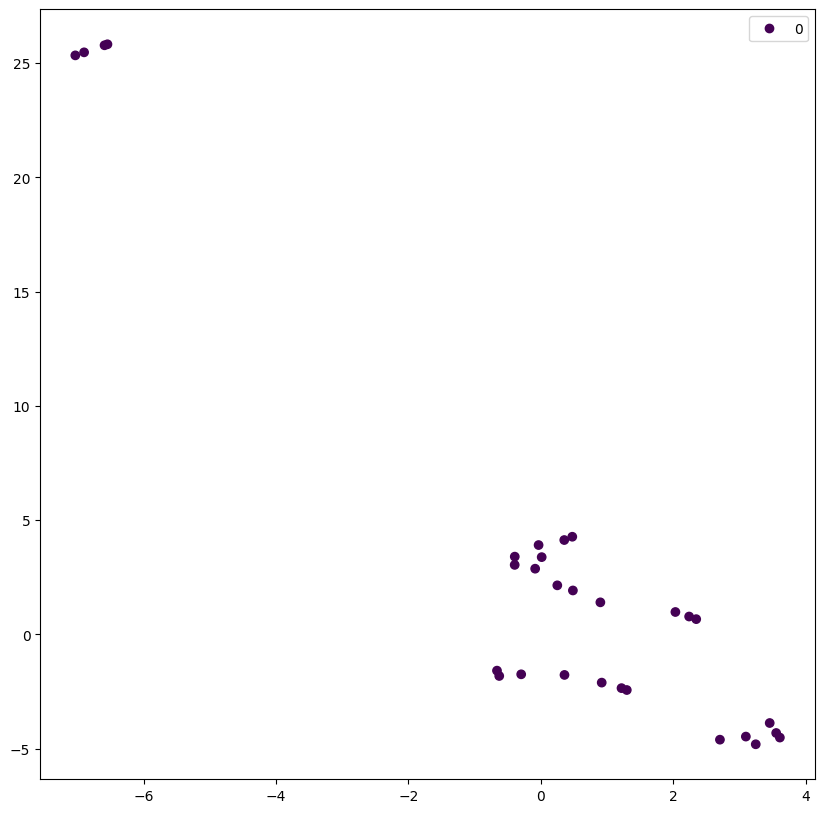

In [ ]:
!pip3 install umap-learn
from umap import UMAP

x_umap = UMAP(n_neighbors=4, min_dist=0.1, metric='correlation').fit_transform(Y)

plt.figure(figsize=(10,10))
sc = plt.scatter(x_umap[:, 0], x_umap[:, 1], c=predicted_labels)
plt.legend(handles=sc.legend_elements()[0], labels=list(range(10)))
plt.show()